# gpu 세팅

In [ ]:
!nvidia-smi

In [ ]:
import torch
print(torch.cuda.is_available())

## torch 버전 낮추기

In [ ]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

## 확인

In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from scipy import io

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# 데이터 준비

In [4]:
data = io.loadmat('data/cylinder_nektar_wake.mat')

In [5]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X_star', 't', 'U_star', 'p_star'])

## 시공간(spacetime)

In [6]:
N = 5000

T = data['t'][:,0:1]
X = data['X_star'][:,0:1]
Y = data['X_star'][:,1:2]

TT = np.repeat(T,len(X)).reshape(-1,1) #repeat :각 요소를 반복
XX = np.tile(X,(len(T),1)).reshape(-1,1)  #tile: 배열 전체를 반복
YY = np.tile(Y,(len(T),1)).reshape(-1,1)

print(f'T 크기: {T.shape}, type(T): {type(T)}')
print(f'X 크기: {X.shape}, type(X): {type(X)}')
print(f'Y 크기: {Y.shape}, type(Y): {type(Y)}')
print('==================================================')

#잘 만들었는지 중간 확인
print(f'TT 크기: {TT.shape}, 5000번째:{TT[4999]}, 5001번째: {TT[5000]}')
print(f'XX 크기: {XX.shape}, 1번째:{XX[0]}, 5000번째: {XX[4999]}')
print(f'YY 크기: {YY.shape}, 1번째:{YY[0]}, 5000번째: {YY[4999]}')

#npmeshgrid 사용

T 크기: (200, 1), type(T): <class 'numpy.ndarray'>
X 크기: (5000, 1), type(X): <class 'numpy.ndarray'>
Y 크기: (5000, 1), type(Y): <class 'numpy.ndarray'>
TT 크기: (1000000, 1), 5000번째:[0.], 5001번째: [0.1]
XX 크기: (1000000, 1), 1번째:[1.], 5000번째: [8.]
YY 크기: (1000000, 1), 1번째:[-2.], 5000번째: [2.]


### tile,repeat 연습

In [ ]:
a= np.array([[1,2,3]]).reshape(-1,1)

b = np.tile(a,2)
c = np.repeat(a,2)
d = np.tile(a,(2,1))
print(a.shape)
print(a)
print(b)
print(b.shape)
print(c)
print(d)
print(d.shape)

## 속도장(velocity field)

In [7]:
#U_star 생김새 관찰
U1 = data['U_star']
print(f'U1 크기: {U1.shape}, type(U1): {type(U1)}') #2행 200열이 5000개 있는 배열
print(U1)
print("=============================================================================")

U2 = data['U_star'][:,0,:]
print(f'U2 크기: {U2.shape}, type(U2): {type(U2)}')
print(U2)
print("=============================================================================")

U_po = data['U_star'][:,0,:].transpose().reshape(-1,1)
V_po = data['U_star'][:,1,:].transpose().reshape(-1,1)

print(f'U_po 크기: {U_po.shape}, t=1/1번째:{U_po[0]}, t=1/5000번째: {U_po[4999]}')
print("=============================================================================")
print(f'V_po 크기: {V_po.shape}, t=1/1번째:{V_po[0]}, t=1/5000번째: {V_po[4999]}')
print("=============================================================================")


U1 크기: (5000, 2, 200), type(U1): <class 'numpy.ndarray'>
[[[ 1.11419216e+00  1.11755721e+00  1.11956933e+00 ...  1.16105653e+00
    1.16209316e+00  1.16287446e+00]
  [-4.09649775e-03  1.09212754e-03  3.28231641e-03 ... -1.14679740e-02
   -1.46226631e-02 -1.78649950e-02]]

 [[ 1.11102707e+00  1.11424311e+00  1.11623549e+00 ...  1.16119046e+00
    1.16250501e+00  1.16355997e+00]
  [ 3.93130751e-04  6.09231658e-03  8.54240777e-03 ... -3.69331211e-03
   -6.90960992e-03 -1.02375054e-02]]

 [[ 1.10748452e+00  1.11049848e+00  1.11244362e+00 ...  1.16080365e+00
    1.16241577e+00  1.16375737e+00]
  [ 4.42777717e-03  1.06585027e-02  1.33831464e-02 ...  4.14245483e-03
    8.86993440e-04 -2.50609725e-03]]

 ...

 [[ 1.04183122e+00  1.07052197e+00  1.08570786e+00 ...  1.03561691e+00
    1.01482352e+00  9.95607444e-01]
  [-1.53233747e-01 -1.52906494e-01 -1.50934775e-01 ...  1.70410243e-01
    1.74234015e-01  1.74978509e-01]]

 [[ 1.03144583e+00  1.05940483e+00  1.07424671e+00 ...  1.05086925e+00
  

### u,v 원하는 shape으로 갖고 오는 법 시도해보기

In [ ]:
a = np.array([1,2,3,4,5,6,7,8,9]).reshape(3,3)

b = a[:,0:1] #t=1일 때 u를 갖고와서 이걸 t=200 까지 반복해서 합치는 방식 => 더 쉬운 방법 있을 것 같음.

#전치하면 행이 같은 t에 대한 u 됨. => reshape 하면 원하는 목표 이룰 수 있음
c = a.transpose()
d = c.reshape(-1,1)
print(f'{a}, shape={a.shape}')
print("\n")
print(f'{b}, shape={b.shape}')
print("\n")
print(f'{c}, shape={c.shape}')
print("\n")
print(f'{d}, shape={d.shape}')

## train data

In [8]:
#이제 N개 뽑아보자.
np.random.seed(0)
idx = np.random.choice(len(TT),N, replace = False)

t_t = TT[idx]
x_t = XX[idx]
y_t = YY[idx]
u_po = U_po[idx]
v_po = V_po[idx]

txy_t = np.hstack((t_t,x_t,y_t))

print(f't_t 크기: {t_t.shape}, t_t[0]: {t_t[0]}')
print(f'x_t 크기: {x_t.shape}, x_t[0]: {x_t[0]}')
print(f'y_t 크기: {y_t.shape}, y_t[0]: {y_t[0]}')
print(f'u_po 크기: {u_po.shape}, u_po[0]: {u_po[0]}')
print(f'v_po 크기: {v_po.shape}, v_po[0]: {v_po[0]}')
print("랜덤으로 뽑은거 안 바뀌는지 확인")
print(f"t:{t_t[0]}, x:{x_t[0]}, y:{y_t[0]}, u:{u_po[0]}, v:{v_po[0]}")
print("=====================================================================================")
print(f'txy_t 크기: {txy_t.shape},   txy:{txy_t[0]}')

t_t 크기: (5000, 1), t_t[0]: [3.1]
x_t 크기: (5000, 1), x_t[0]: [1.35353535]
y_t 크기: (5000, 1), y_t[0]: [-0.28571429]
u_po 크기: (5000, 1), u_po[0]: [-0.11721427]
v_po 크기: (5000, 1), v_po[0]: [-0.21641754]
랜덤으로 뽑은거 안 바뀌는지 확인
t:[3.1], x:[1.35353535], y:[-0.28571429], u:[-0.11721427], v:[-0.21641754]
txy_t 크기: (5000, 3),   txy:[ 3.1         1.35353535 -0.28571429]


### noisy train data

In [9]:
np.random.seed(42)
noise = 0.01
u_npo = u_po + noise*np.std(u_po)*np.random.randn(N,1)
v_npo = v_po + noise*np.std(v_po)*np.random.randn(N,1)

print(f'u_npo 크기: {u_npo.shape}, u_npo[0]: {u_npo[0]}')
print(f'v_npo 크기: {v_npo.shape}, v_npo[0]: {v_npo[0]}')


u_npo 크기: (5000, 1), u_npo[0]: [-0.11580686]
v_npo 크기: (5000, 1), v_npo[0]: [-0.21758377]


### tensor로 변환

In [10]:
txy_t = torch.tensor(txy_t, requires_grad=True, dtype=torch.float32).to(device)
u_po = torch.tensor(u_po,dtype=torch.float32).to(device)
v_po = torch.tensor(v_po,dtype=torch.float32).to(device)
u_npo = torch.tensor(u_npo,dtype=torch.float32).to(device)
v_npo= torch.tensor(v_npo,dtype=torch.float32).to(device)

# MLP 만들기

In [11]:
class PINN(nn.Module):
    def __init__(self) :                    
        super(PINN, self).__init__()
        #람다 학습 파라미터로 설정
        self.lambda1 = nn.Parameter(torch.tensor([0.0])) 
        self.lambda2 = nn.Parameter(torch.tensor([0.0]))

        #레이어 만들기
        self.linear1 = nn.Linear(3, 20) #입력: (t,x,y), 한 layer당 20뉴런 => (weight:(100,3)행렬 생성, bias:(100,)벡터 생성
        nn.init.xavier_normal_(self.linear1.weight) # w의 쓰레기값 대신 정규분포(mean=0, std=sqrt(2/3+20) 내의 값으로 변환
        
        self.linear2 = nn.Linear(20, 20)
        nn.init.xavier_normal_(self.linear2.weight)

        self.linear3 = nn.Linear(20, 20)
        nn.init.xavier_normal_(self.linear3.weight)
        
        self.linear4 = nn.Linear(20, 20)
        nn.init.xavier_normal_(self.linear4.weight)

        self.linear5 = nn.Linear(20, 20)
        nn.init.xavier_normal_(self.linear5.weight)

        self.linear6 = nn.Linear(20, 20)
        nn.init.xavier_normal_(self.linear6.weight)

        self.linear7 = nn.Linear(20, 20)
        nn.init.xavier_normal_(self.linear7.weight)

        self.linear8 = nn.Linear(20, 20)
        nn.init.xavier_normal_(self.linear8.weight)

        self.linear9 = nn.Linear(20, 2) #출력 :[ψ(t, x, y) p(t, x, y)]
        nn.init.xavier_normal_(self.linear9.weight)

        self.act = nn.Tanh()                         # Nonlinear activation function

    def forward(self, x) :
        h1 = self.act(self.linear1(x))
        h2 = self.act(self.linear2(h1))
        h3 = self.act(self.linear3(h2))
        h4 = self.act(self.linear4(h3))
        h5 = self.act(self.linear5(h4))
        h6 = self.act(self.linear6(h5))
        h7 = self.act(self.linear7(h6))
        h8 = self.act(self.linear8(h7))
        output = self.linear9(h8)  #output에는 activation funtion 없음. 
        return output 

# predict function

In [12]:
def predict(pinn,x):
    output = pinn(x)
    psi_o = output[:,0:1]
    p_o = output[:,1:2]
    
    u_pr = torch.autograd.grad(outputs = psi_o.sum(), inputs = x, create_graph=True)[0][:,2:3] #psi_y = u
    v_pr = -torch.autograd.grad(outputs = psi_o.sum(), inputs = x, create_graph=True)[0][:,1:2] #-psi_x = v

    return u_pr, v_pr, p_o

    

# loss function 

## loss_uv

In [103]:
def loss_uv(u_pr, v_pr, u, v):

    mse_uv = ((u_pr - u)**2 + (v_pr - v)**2).mean()

    #print(f'(u_pr - u)**2: {(u_pr - u)**2}, (u_pr - u)**2 shape: {((u_pr - u)**2).shape}, mse_uv.shape: {mse_uv.shape}')
    
    return mse_uv

## loss_fg

### make f,g function

f := u_t + λ1(uu_x + vu_y) + p_x - λ2(u_xx + u_yy) 
g:= v_t + λ1(uv_x + vv_y) + p_y - λ2(v_xx + v_yy)

In [14]:
def navier_f(lambda1, lambda2, u_pr, v_pr, p_o, x):

    u_pr_t = torch.autograd.grad(outputs = u_pr.sum(), inputs = x, create_graph=True)[0][:,0:1] 
    u_pr_x = torch.autograd.grad(outputs = u_pr.sum(), inputs = x, create_graph=True)[0][:,1:2]
    u_pr_y = torch.autograd.grad(outputs = u_pr.sum(), inputs = x, create_graph=True)[0][:,2:3]

    p_o_x = torch.autograd.grad(outputs = p_o.sum(), inputs = x, create_graph=True)[0][:,1:2]
    
    u_pr_xx = torch.autograd.grad(outputs = u_pr_x.sum(), inputs = x, create_graph=True)[0][:,1:2]
    u_pr_yy = torch.autograd.grad(outputs = u_pr_y.sum(), inputs = x, create_graph=True)[0][:,2:3]

    f = u_pr_t + lambda1*(u_pr*u_pr_x + v_pr*u_pr_y) + p_o_x - lambda2*(u_pr_xx + u_pr_yy)
    
    return f

In [15]:
def navier_g(lambda1, lambda2, u_pr, v_pr, p_o, x):

    v_pr_t = torch.autograd.grad(outputs = v_pr.sum(), inputs = x, create_graph=True)[0][:,0:1] 
    v_pr_x = torch.autograd.grad(outputs = v_pr.sum(), inputs = x, create_graph=True)[0][:,1:2]
    v_pr_y = torch.autograd.grad(outputs = v_pr.sum(), inputs = x, create_graph=True)[0][:,2:3]

    p_o_y = torch.autograd.grad(outputs = p_o.sum(), inputs = x, create_graph=True)[0][:,2:3]
    
    v_pr_xx = torch.autograd.grad(outputs = v_pr_x.sum(), inputs = x, create_graph=True)[0][:,1:2]
    v_pr_yy = torch.autograd.grad(outputs = v_pr_y.sum(), inputs = x, create_graph=True)[0][:,2:3]

    g = v_pr_t + lambda1*(u_pr*v_pr_x + v_pr*v_pr_y) + p_o_y - lambda2*(v_pr_xx + v_pr_yy)
    
    return g

In [16]:
def loss_fg(lambda1, lambda2, u_pr, v_pr, p_o, x):
    
    f = navier_f(lambda1, lambda2, u_pr, v_pr, p_o, x)
    g = navier_g(lambda1, lambda2, u_pr, v_pr, p_o, x)
    
    mse_fg = (f**2 + g**2).mean()
    
    return mse_fg

# clean

## train(clean)

### train setting

In [84]:
pinn = PINN().to(device)

opti_adam = torch.optim.Adam(pinn.parameters())


### adam

In [88]:
pinn.train()

#adam
for _ in tqdm(range(1,N+1)):
    opti_adam.zero_grad()
    
    u_pr, v_pr, p_o = predict(pinn,txy_t)
    
    loss = loss_uv(u_pr, v_pr, u_po, v_po) + loss_fg(pinn.lambda1, pinn.lambda2, u_pr, v_pr, p_o, txy_t)
    loss.backward()
    
    opti_adam.step()
    
torch.save(
            pinn.state_dict(),
            f"./Navier-Stokes-Identification_weight.pt",
        )

    

  0%|          | 0/5000 [00:00<?, ?it/s]

#### 아담 최적화 후 중간점검

In [89]:
checkpoint = torch.load("./Navier-Stokes-Identification_weight.pt")
print(checkpoint.keys())

odict_keys(['lambda1', 'lambda2', 'linear1.weight', 'linear1.bias', 'linear2.weight', 'linear2.bias', 'linear3.weight', 'linear3.bias', 'linear4.weight', 'linear4.bias', 'linear5.weight', 'linear5.bias', 'linear6.weight', 'linear6.bias', 'linear7.weight', 'linear7.bias', 'linear8.weight', 'linear8.bias', 'linear9.weight', 'linear9.bias'])


/tmp/ipykernel_9861/3527058755.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./Navier-Stokes-Identification_weight.pt")


In [90]:
print(f'linear9.weight: {pinn.linear9.weight}, linear9.weight(shape): {pinn.linear9.weight.shape}')
print("=========================================================================================")
print(f'linear9.bias: {pinn.linear9.bias}, linear9.bias(shape): {pinn.linear9.bias.shape}')
print("=========================================================================================")
print(f'lambda1:{pinn.lambda1}, lambda2:{pinn.lambda2}')

linear9.weight: Parameter containing:
tensor([[ 0.4669, -0.0089, -0.0302, -0.3839,  0.1631, -0.9470, -0.1885, -1.0150,
         -0.6476,  0.7324, -1.1345,  0.4422, -0.3824,  0.3451, -0.8832, -0.3433,
         -0.7532,  0.6451,  0.3682, -0.2167],
        [ 0.1306,  0.5428, -0.7236, -0.0715, -0.6494, -1.0240,  0.5343, -0.0346,
         -0.3105, -0.3409,  0.4575,  0.7963,  0.0738,  0.5767, -0.2085, -0.8585,
          0.7410, -0.8131, -0.3441, -0.3348]], device='cuda:0',
       requires_grad=True), linear9.weight(shape): torch.Size([2, 20])
linear9.bias: Parameter containing:
tensor([ 0.0880, -0.0524], device='cuda:0', requires_grad=True), linear9.bias(shape): torch.Size([2])
lambda1:Parameter containing:
tensor([0.8863], device='cuda:0', requires_grad=True), lambda2:Parameter containing:
tensor([0.0155], device='cuda:0', requires_grad=True)


In [91]:
opti_lbfgs = torch.optim.LBFGS(
    pinn.parameters(),
    max_iter=5000,
    max_eval=5000,
    history_size=50,        # maxcor
    tolerance_change=1.0 * np.finfo(float).eps,
    line_search_fn="strong_wolfe"
)

### LBFGS

In [92]:
# txy_t = txy_t.detach().requires_grad_(True)
iter = 0
def closure():
    opti_lbfgs.zero_grad()
    
    u_pr, v_pr, p_o = predict(pinn,txy_t)

    loss = loss_uv(u_pr, v_pr, u_po, v_po) + loss_fg(pinn.lambda1, pinn.lambda2, u_pr, v_pr, p_o, txy_t)
    loss.backward()

    #진행상황 확인용
    global iter
    iter += 1
    if iter%200 == 0:
        print(f"iter: {iter}, loss: {loss.item():.3e}, lambda1: {pinn.lambda1.item():.5f}, lambda2: {pinn.lambda2.item():.5f}")
            
    return loss
        
opti_lbfgs.step(closure)

torch.save(
            pinn.state_dict(),
            f"./Navier-Stokes-Identification_weight(after_lbfgs).pt",
        )


iter: 200, loss: 2.758e-02, lambda1: 0.90941, lambda2: 0.01386
iter: 400, loss: 2.128e-02, lambda1: 0.90278, lambda2: 0.01495
iter: 600, loss: 1.597e-02, lambda1: 0.90003, lambda2: 0.01554
iter: 800, loss: 1.285e-02, lambda1: 0.91326, lambda2: 0.01493
iter: 1000, loss: 1.129e-02, lambda1: 0.92822, lambda2: 0.01310
iter: 1200, loss: 1.008e-02, lambda1: 0.92580, lambda2: 0.01241
iter: 1400, loss: 9.111e-03, lambda1: 0.93562, lambda2: 0.01244
iter: 1600, loss: 8.071e-03, lambda1: 0.94573, lambda2: 0.01280
iter: 1800, loss: 7.249e-03, lambda1: 0.94882, lambda2: 0.01178
iter: 2000, loss: 6.703e-03, lambda1: 0.96303, lambda2: 0.01292
iter: 2200, loss: 6.235e-03, lambda1: 0.96062, lambda2: 0.01305
iter: 2400, loss: 5.807e-03, lambda1: 0.96329, lambda2: 0.01298
iter: 2600, loss: 5.429e-03, lambda1: 0.96301, lambda2: 0.01425
iter: 2800, loss: 5.101e-03, lambda1: 0.96987, lambda2: 0.01410
iter: 3000, loss: 4.774e-03, lambda1: 0.96882, lambda2: 0.01456
iter: 3200, loss: 4.481e-03, lambda1: 0.9658

논문 lambda1=0.999, lambda2=0.01047

## p 시각화(clean)

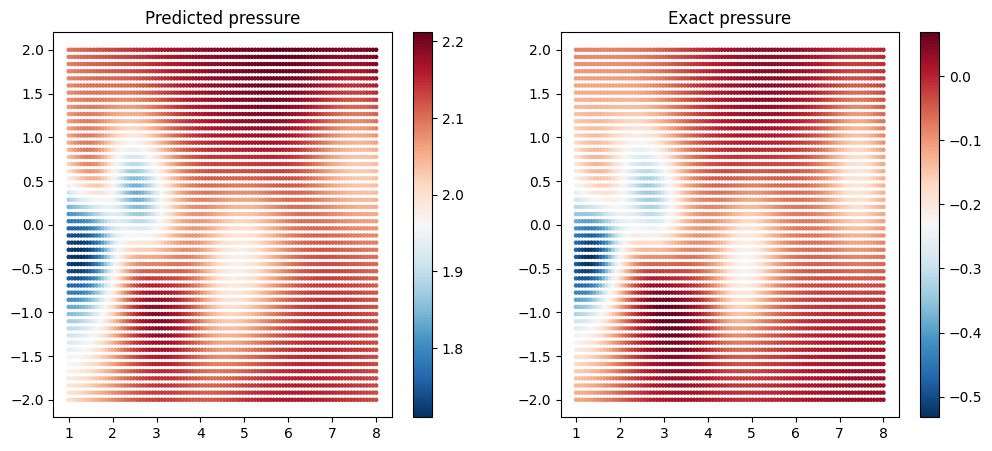

In [93]:
pinn.eval()

#논문처럼 p에 대해 시각화 같은 t에 대한 x,y가 필요
t_static = 5
t = TT[N*t_static:N*(t_static+1)]
x = XX[N*t_static:N*(t_static+1)]
y = YY[N*t_static:N*(t_static+1)]

txy = np.hstack((t,x,y))

txy = torch.tensor(txy, requires_grad=True, dtype=torch.float32).to(device)
_,_,p_o = predict(pinn, txy)

p_o = p_o.cpu().detach().numpy()
p_po = data['p_star'][:,t_static]

#시각화
_, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(x, y, c=p_o, cmap='RdBu_r', s=5)
axes[0].set_title('Predicted pressure')

axes[1].scatter(x, y, c=p_po, cmap='RdBu_r', s=5)
axes[1].set_title('Exact pressure')

plt.colorbar(axes[0].collections[0], ax=axes[0])
plt.colorbar(axes[1].collections[0], ax=axes[1])

plt.show()

# noise

## train(noise)

### train setting

In [99]:
pinn = PINN().to(device)

opti_adam = torch.optim.Adam(pinn.parameters())

### adam

In [ ]:
pinn.train()

#adam
for _ in tqdm(range(1,N+1)):
    opti_adam.zero_grad()
    
    u_pr, v_pr, p_o = predict(pinn,txy_t)
    
    loss_n = loss_uv(u_pr, v_pr, u_npo, v_npo) + loss_fg(pinn.lambda1, pinn.lambda2, u_pr, v_pr, p_o, txy_t)
    loss_n.backward()
    
    opti_adam.step()
    
torch.save(
            pinn.state_dict(),
            f"./Navier-Stokes-Identification_weight(noise).pt",
        )

  0%|          | 0/5000 [00:00<?, ?it/s]

(u_pr - u)**2: tensor([[0.0261],
        [0.8358],
        [0.8679],
        ...,
        [0.6341],
        [1.2307],
        [0.8637]], device='cuda:0', grad_fn=<PowBackward0>), (u_pr - u)**2 shape: torch.Size([5000, 1]), mse_uv.shape: torch.Size([])
(u_pr - u)**2: tensor([[0.0370],
        [0.8042],
        [0.8372],
        ...,
        [0.6232],
        [1.2205],
        [0.8535]], device='cuda:0', grad_fn=<PowBackward0>), (u_pr - u)**2 shape: torch.Size([5000, 1]), mse_uv.shape: torch.Size([])
(u_pr - u)**2: tensor([[0.0500],
        [0.7762],
        [0.8108],
        ...,
        [0.6110],
        [1.2098],
        [0.8418]], device='cuda:0', grad_fn=<PowBackward0>), (u_pr - u)**2 shape: torch.Size([5000, 1]), mse_uv.shape: torch.Size([])
(u_pr - u)**2: tensor([[0.0663],
        [0.7488],
        [0.7861],
        ...,
        [0.5970],
        [1.1975],
        [0.8279]], device='cuda:0', grad_fn=<PowBackward0>), (u_pr - u)**2 shape: torch.Size([5000, 1]), mse_uv.shape: torch.S

#### 아담 최적화 후 중간점검

In [101]:
checkpoint = torch.load("./Navier-Stokes-Identification_weight(noise).pt")
print(checkpoint.keys())

odict_keys(['lambda1', 'lambda2', 'linear1.weight', 'linear1.bias', 'linear2.weight', 'linear2.bias', 'linear3.weight', 'linear3.bias', 'linear4.weight', 'linear4.bias', 'linear5.weight', 'linear5.bias', 'linear6.weight', 'linear6.bias', 'linear7.weight', 'linear7.bias', 'linear8.weight', 'linear8.bias', 'linear9.weight', 'linear9.bias'])


/tmp/ipykernel_9861/892808493.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./Navier-Stokes-Identification_weight(noise).pt")


In [60]:
print(f'linear9.weight: {pinn.linear9.weight}, linear9.weight(shape): {pinn.linear9.weight.shape}')
print("=========================================================================================")
print(f'linear9.bias: {pinn.linear9.bias}, linear9.bias(shape): {pinn.linear9.bias.shape}')
print("=========================================================================================")
print(f'lambda1:{pinn.lambda1}, lambda2:{pinn.lambda2}')

linear9.weight: Parameter containing:
tensor([[-0.9195, -0.4356, -0.3420, -0.4433, -0.2506, -0.1879,  0.2306,  0.1670,
         -0.2124,  0.3633, -0.3867,  0.6136, -0.3420,  0.1351,  0.2206, -0.3466,
         -0.2242,  0.4217,  0.4763, -0.3734],
        [ 0.2457, -0.2405,  0.1080, -0.2841,  0.2373,  0.0787,  0.1904, -1.1041,
         -0.4936,  0.2051, -0.5025,  0.1698,  0.0752, -0.9499,  0.9237,  0.6070,
          0.1980,  0.0055,  0.0429,  0.3804]], device='cuda:0',
       requires_grad=True), linear9.weight(shape): torch.Size([2, 20])
linear9.bias: Parameter containing:
tensor([0.0679, 0.1948], device='cuda:0', requires_grad=True), linear9.bias(shape): torch.Size([2])
lambda1:Parameter containing:
tensor([0.9600], device='cuda:0', requires_grad=True), lambda2:Parameter containing:
tensor([0.0128], device='cuda:0', requires_grad=True)


### LBFGS

In [106]:
opti_lbfgs = torch.optim.LBFGS(
    pinn.parameters(),
    max_iter=5000,
    max_eval=5000,
    history_size=50,        # maxcor
    tolerance_change=1.0 * np.finfo(float).eps,
    line_search_fn="strong_wolfe"
)

In [108]:
txy_t = txy_t.detach().requires_grad_(True)
iter = 0
def closure():
    opti_lbfgs.zero_grad()
    
    u_pr, v_pr, p_o = predict(pinn,txy_t)

    loss_n = loss_uv(u_pr, v_pr, u_npo, v_npo) + loss_fg(pinn.lambda1, pinn.lambda2, u_pr, v_pr, p_o, txy_t)
    loss_n.backward()

    #진행상황 확인용
    global iter
    iter += 1
    if iter%200 == 0:
        print(f"iter: {iter}, loss_n: {loss_n.item():.3e}, lambda1: {pinn.lambda1.item():.3f}, lambda2: {pinn.lambda2.item():.5f}")
            
    return loss_n
        
opti_lbfgs.step(closure)

torch.save(
            pinn.state_dict(),
            f"./Navier-Stokes-Identification_weight(after_lbfgs(noise)).pt",
        )


iter: 200, loss_n: 8.203e-04, lambda1: 0.992, lambda2: 0.01116
iter: 400, loss_n: 8.049e-04, lambda1: 0.991, lambda2: 0.01120
iter: 600, loss_n: 7.891e-04, lambda1: 0.992, lambda2: 0.01108
iter: 800, loss_n: 7.719e-04, lambda1: 0.992, lambda2: 0.01102
iter: 1000, loss_n: 7.552e-04, lambda1: 0.992, lambda2: 0.01101
iter: 1200, loss_n: 7.383e-04, lambda1: 0.992, lambda2: 0.01112
iter: 1400, loss_n: 7.194e-04, lambda1: 0.993, lambda2: 0.01115
iter: 1600, loss_n: 6.977e-04, lambda1: 0.993, lambda2: 0.01118
iter: 1800, loss_n: 6.731e-04, lambda1: 0.994, lambda2: 0.01106
iter: 2000, loss_n: 6.504e-04, lambda1: 0.993, lambda2: 0.01113
iter: 2200, loss_n: 6.302e-04, lambda1: 0.993, lambda2: 0.01122
iter: 2400, loss_n: 6.099e-04, lambda1: 0.992, lambda2: 0.01117
iter: 2600, loss_n: 5.921e-04, lambda1: 0.993, lambda2: 0.01104
iter: 2800, loss_n: 5.743e-04, lambda1: 0.993, lambda2: 0.01098
iter: 3000, loss_n: 5.585e-04, lambda1: 0.993, lambda2: 0.01100
iter: 3200, loss_n: 5.436e-04, lambda1: 0.99

논문 lambda1=0.998, lambda2=0.01057

## p 시각화(noise)

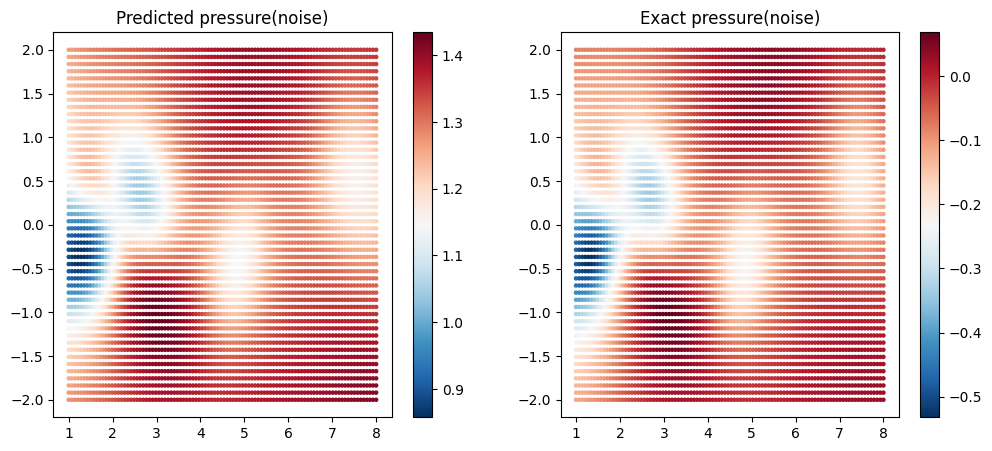

In [109]:
pinn.eval()

#논문처럼 p에 대해 시각화 같은 t에 대한 x,y가 필요
t_static = 5
t = TT[N*t_static:N*(t_static+1)]
x = XX[N*t_static:N*(t_static+1)]
y = YY[N*t_static:N*(t_static+1)]

txy = np.hstack((t,x,y))

txy = torch.tensor(txy, requires_grad=True, dtype=torch.float32).to(device)
_,_,p_o = predict(pinn, txy)

p_o = p_o.cpu().detach().numpy()
p_po = data['p_star'][:,t_static]

#시각화
_, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(x, y, c=p_o, cmap='RdBu_r', s=5)
axes[0].set_title('Predicted pressure(noise)')

axes[1].scatter(x, y, c=p_po, cmap='RdBu_r', s=5)
axes[1].set_title('Exact pressure(noise)')

plt.colorbar(axes[0].collections[0], ax=axes[0])
plt.colorbar(axes[1].collections[0], ax=axes[1])

plt.show()